# Introduction

In this notebook we share some code examples for pricing RWAs with delayed liquidity using `Dope`

In [16]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [510]:
from dope.rwa.stochprocess.gbm_jump import GBMJumpProcess
from dope.rwa.utilities.cara import ImpliedGamma

from dope.rwa.rwa import RWA

Let today be $t = 0$. Next redemption is in $N$ days at $T$.


- What we receive if we wait:

$$
X_{\text{wait}} = (1 - f)\,V_T
$$

(redemption fee $f$, add gates if needed)

- What we receive if we sell now:

$$
X_{\text{sell}} = (1 - h_N)\,V_0
$$

where $h_N$ is the uniswap slippage for today

---

Let's use the exponential utility:

$$
U(x) = -e^{-\gamma x}.
$$

You can read this utility as: "I like to receive money, but I dislike losing money at an exponential rate"

- Certainty equivalent of waiting:


Define $L(X)$ as the sure amount that gives the same expected utility as the risky payoff $X$:

$$
U(L(X)) = \mathbb{E}[U(X)].
$$

This is the definition of “liquidity-equivalent cash” given a utility.

---

**Let's Solve this equation for** $ L(X) $

Plug in \( U \):

$$
- e^{-\gamma L(X)} = \mathbb{E}\left[-e^{-\gamma X}\right].
$$

Cancel the minus:

$$
e^{-\gamma L(X)} = \mathbb{E}\left[e^{-\gamma X}\right].
$$

Take $\ln$ of both sides:

$$
-\gamma L(X) = \ln \mathbb{E}\left[e^{-\gamma X}\right].
$$

Divide by  $-\gamma$:

$$
L(X) = -\frac{1}{\gamma} \ln \mathbb{E}\left[e^{-\gamma X}\right].
$$

---

In [512]:
### Example

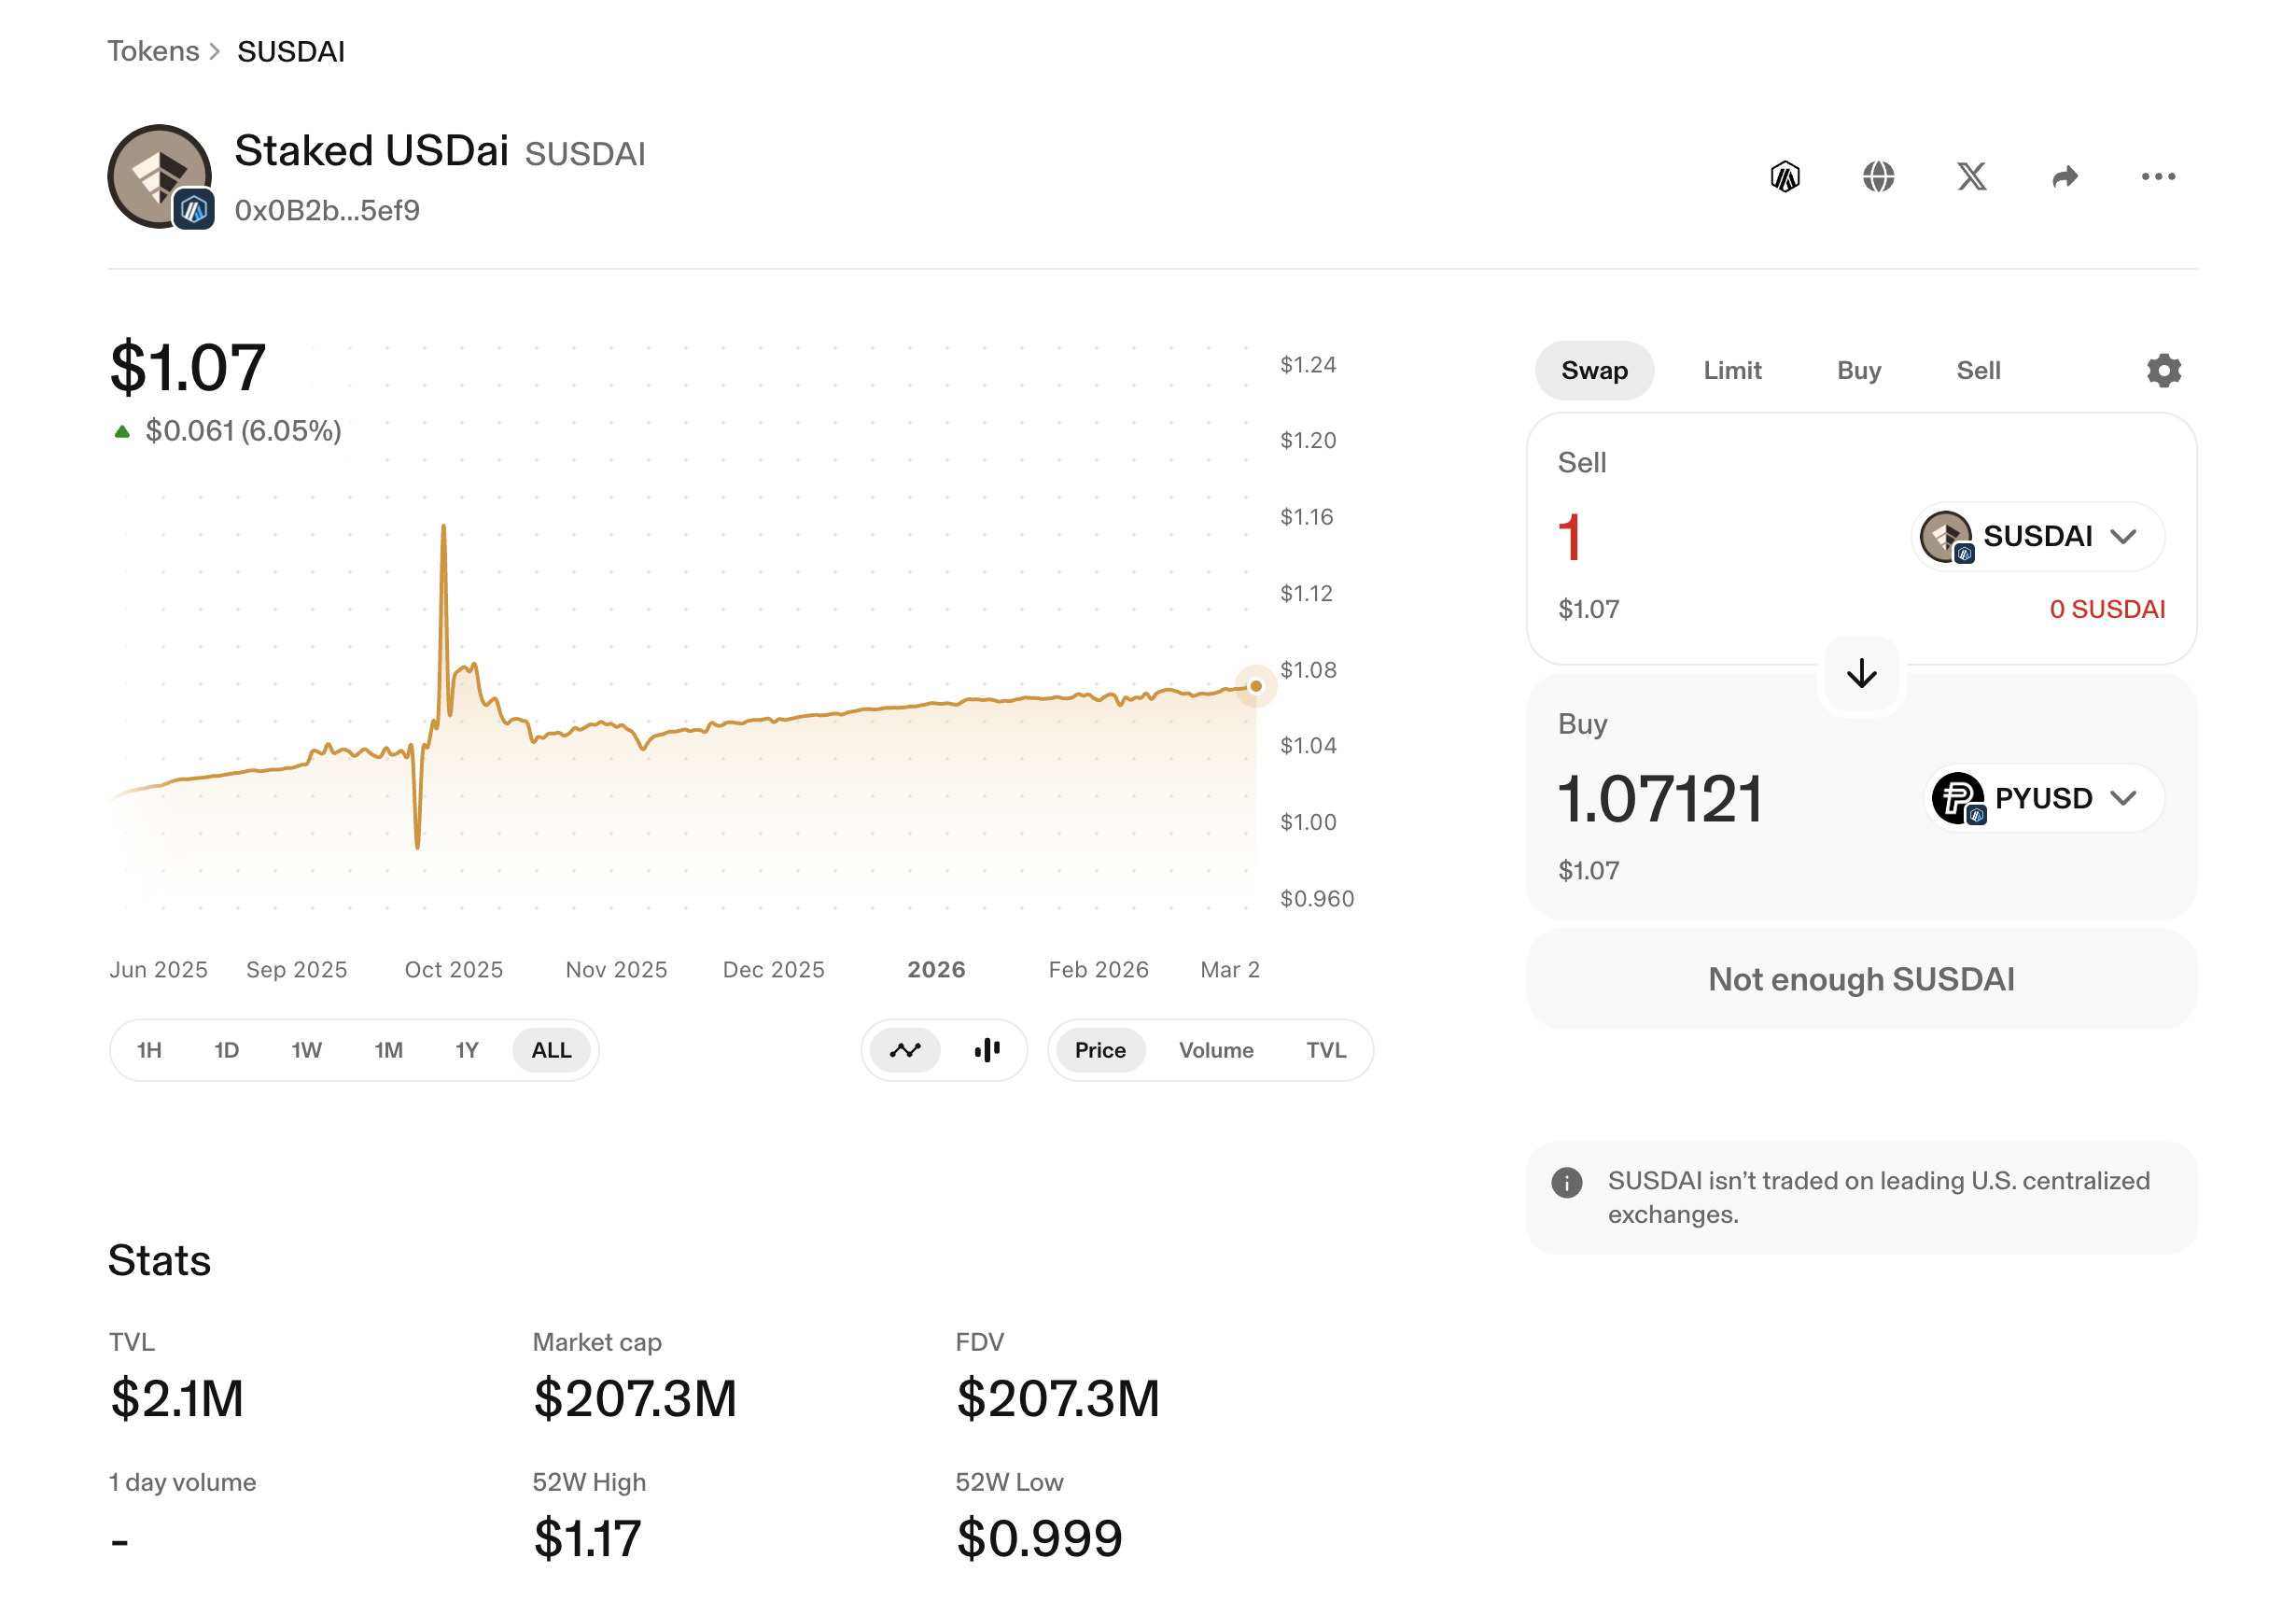

link: https://app.uniswap.org/explore/tokens/arbitrum/0x0b2b2b2076d95dda7817e785989fe353fe955ef9

### How to find your risk aversion $\gamma$ (`gamma`) ?


If you have $1 dollar, and you have to take a bet of receiving 2% more, or losing 2% with equal probability. 
How much would you pay (`target_premium`) to actually not have to do that bet?

From this question, you can compute the implied $\gamma$ that makes sense to use in the examples below

In [511]:
V0 = 1.
r = 0.02
l = 0.02
target_premium = 0.01 * V0 # how much would you pay to avoid this bet?

model = ImpliedGamma(V0)
gamma = model.solve_gamma(
    r=r,
    l=l,
    target_premium=target_premium,
    p=0.5,
)
gamma

60.93778648476301

# How to price sUSDai as a `GBM`

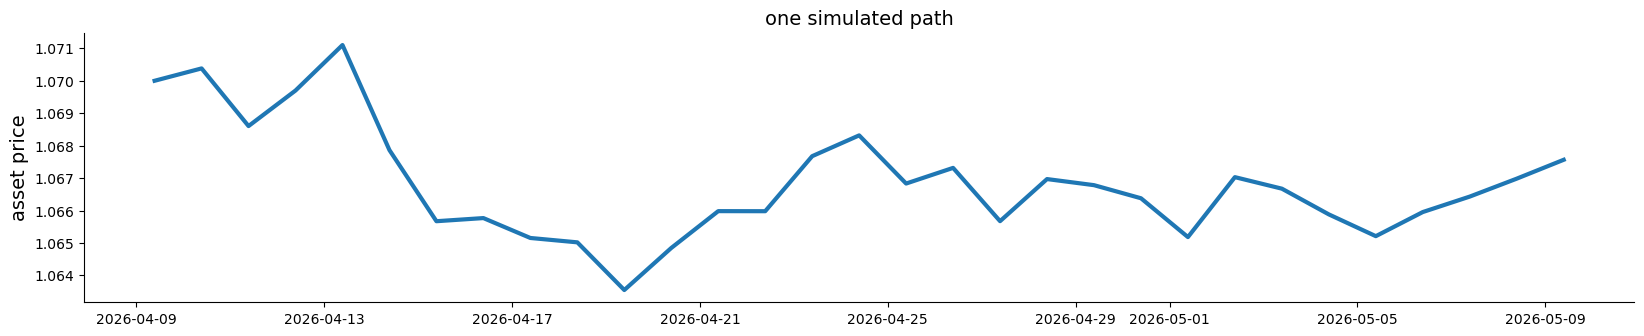

Decision: SELL
I sell if I get more than         : 1.064444583300873
Current swap price (with slippage): 1.06465


In [513]:
from dope.rwa import RWA

rwa = RWA(
    V0=1.07,
    gamma=gamma,
    model="gbm",
    model_params={
        "mu": -0.0001*365.25,
        "sigma": 0.0015*np.sqrt(365.25),
    },
    seed=42,
)
gbm_path = rwa.simulate_path_with_timestamps(n_days=30, step_size=1)

decision = rwa.decide(n_days=30, slippage=0.005)

print("Decision:", decision["decision"])
print("I sell if I get more than         :", decision["L_wait"])
print("Current swap price (with slippage):", decision["X_sell"])

# How to price sUSDai as a `GMB` with Jumps (jump-diffusion) model

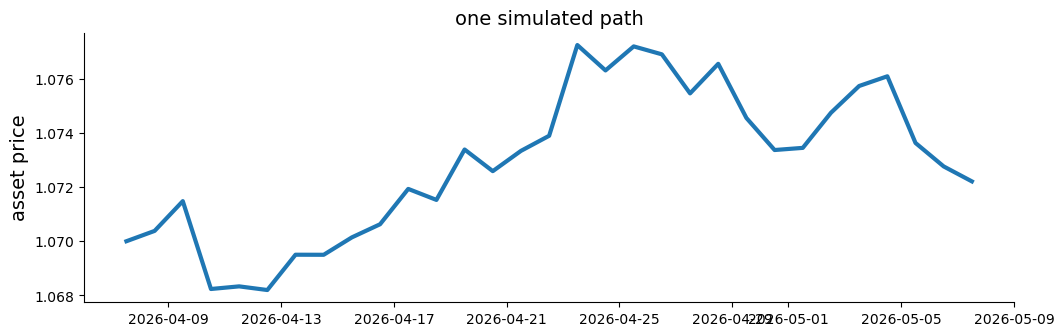

Decision: SELL
I sell if I get more than         : 1.0644945248399202
Current swap price (with slippage): 1.06465


In [48]:
from dope.rwa import RWA

rwa = RWA(
    V0=1.07,
    gamma=gamma,
    model="gbm_jump",
    model_params={
        "mu": -0.0001*365.25,
        "sigma": 0.0015*np.sqrt(365.25),
        "lambda_pos": 0.1,
        "lambda_neg": 0.0,
        "jump_mean_pos": 0.0,
        "jump_std_pos": 0.01*np.sqrt(365.25),
        "jump_mean_neg": -0.12*365.25,
        "jump_std_neg": 0.05*np.sqrt(365.25),
    },
    seed=42,
)
gbm_path = rwa.simulate_path_with_timestamps(n_days=30)


decision = rwa.decide(n_days=30, slippage=0.005)

print("Decision:", decision["decision"])
print("I sell if I get more than         :", decision["L_wait"])
print("Current swap price (with slippage):", decision["X_sell"])

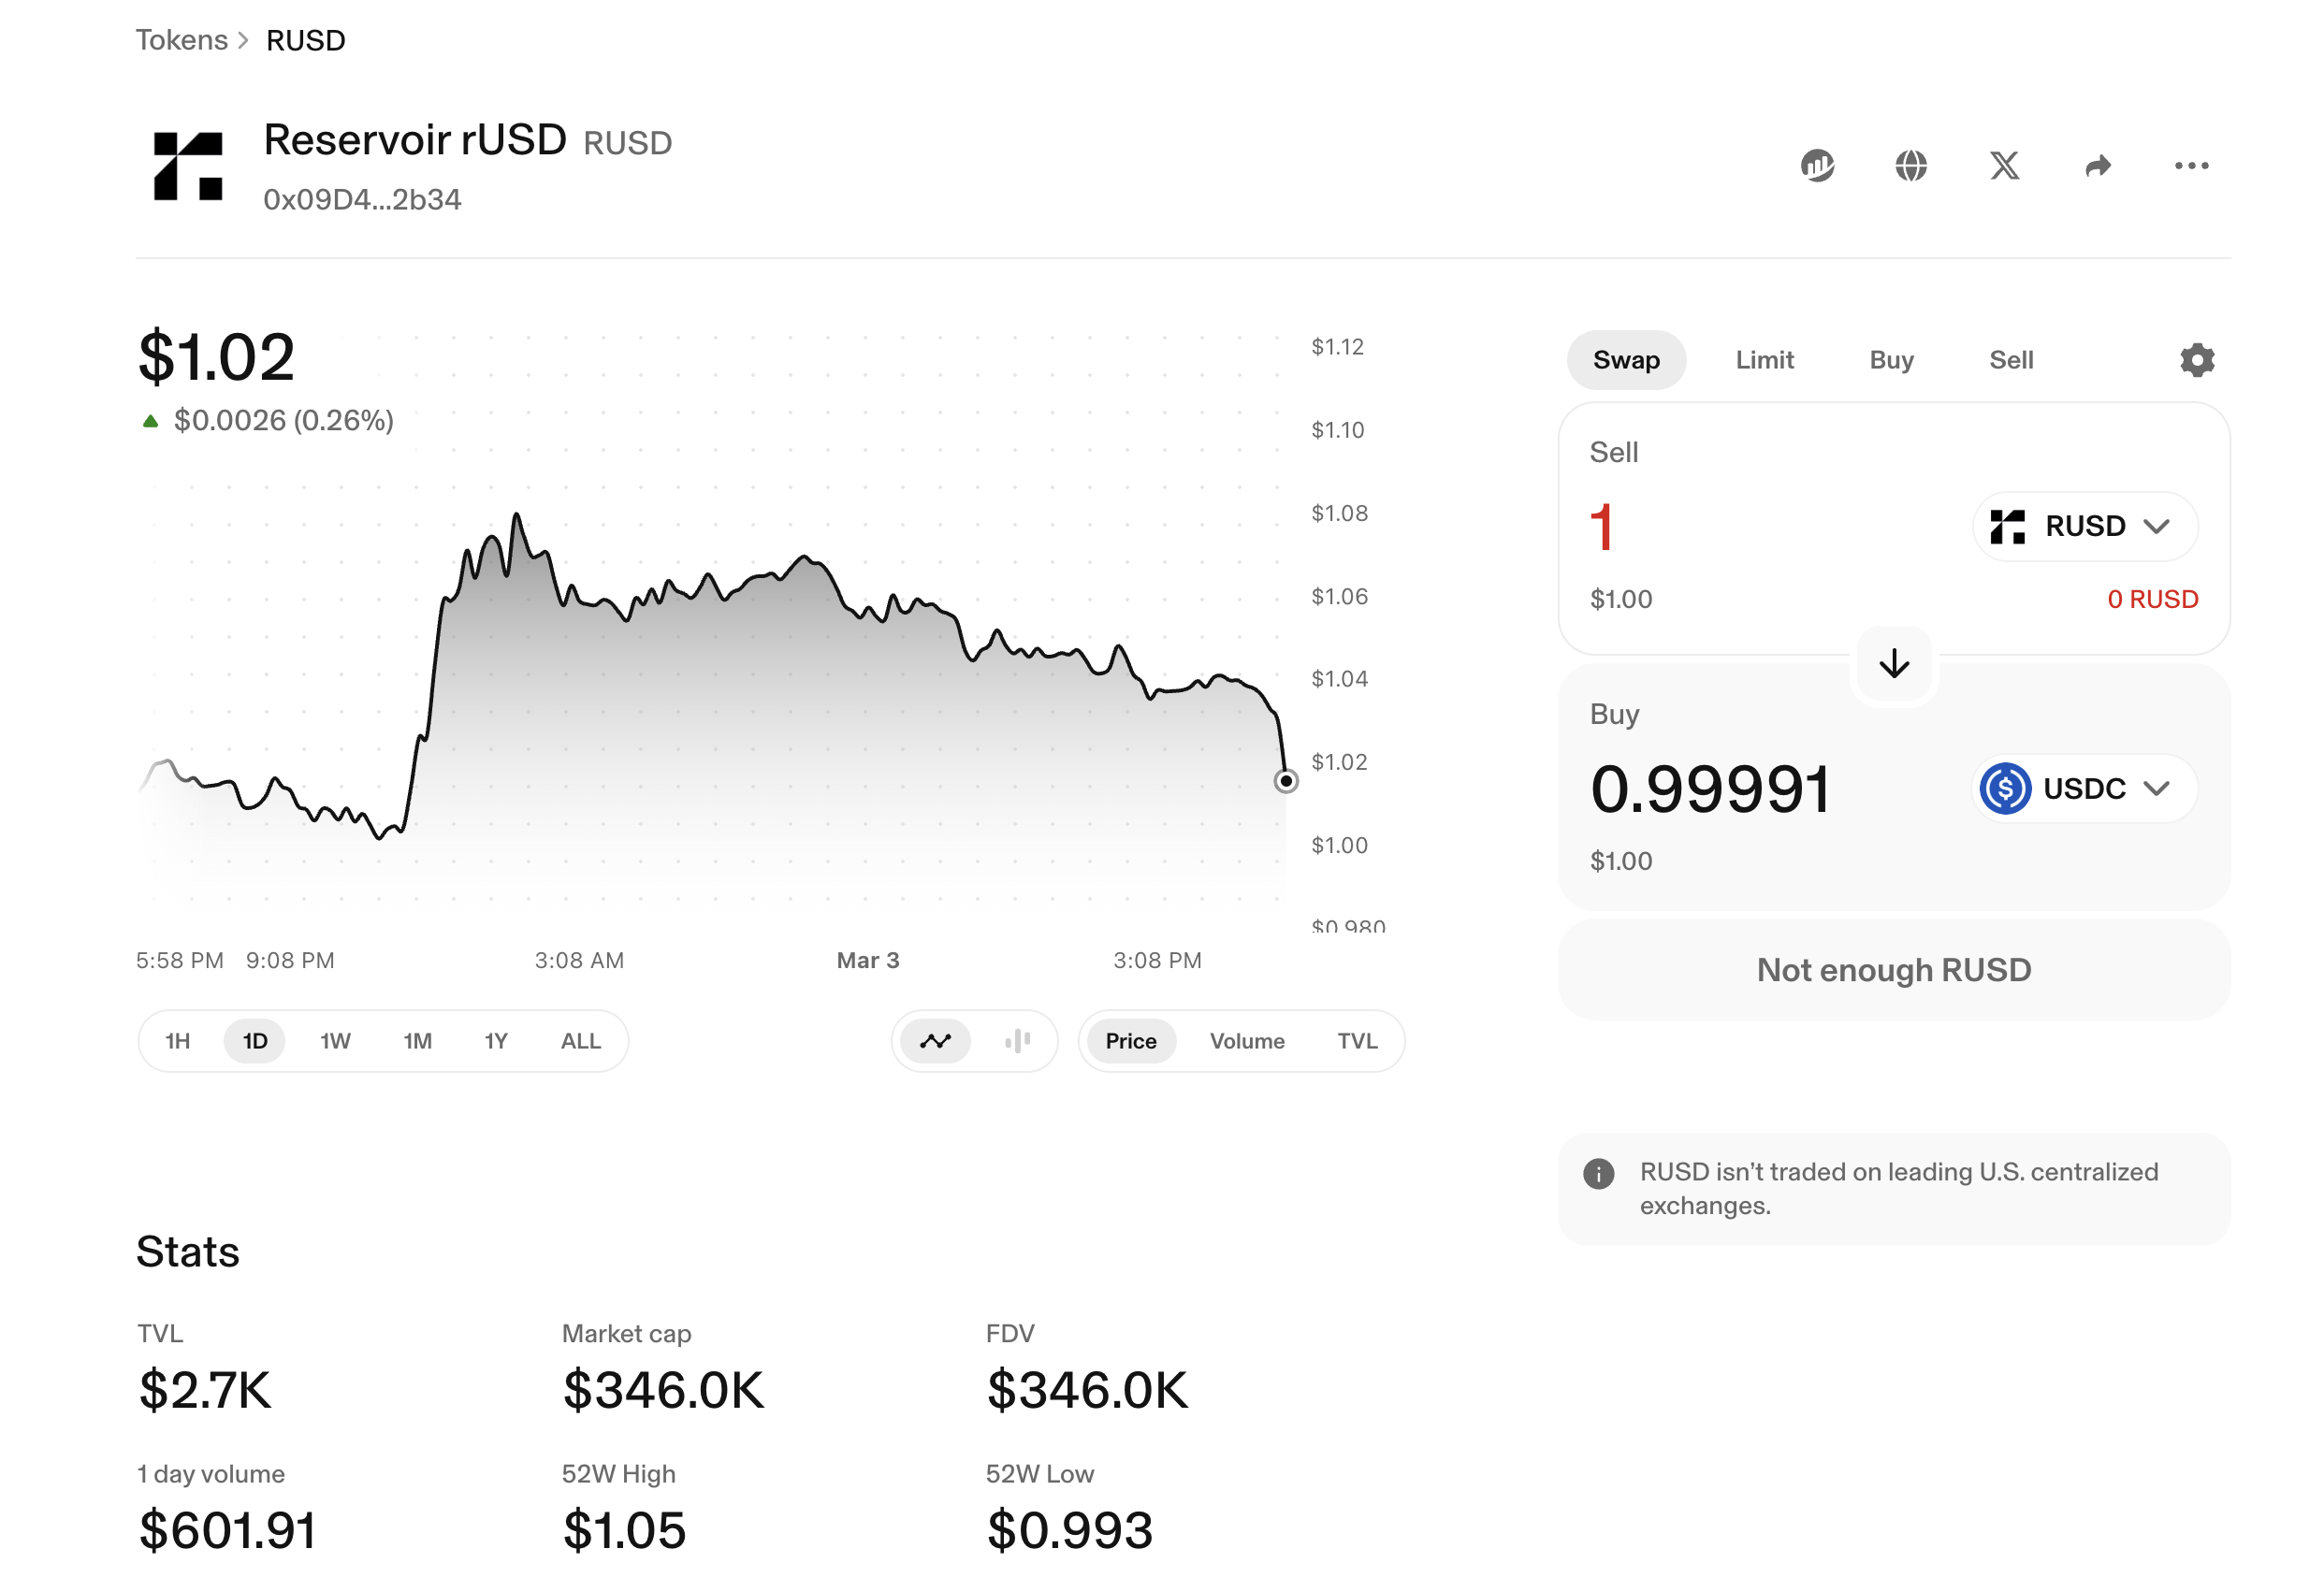

# How to price rUSD as a `GBM`

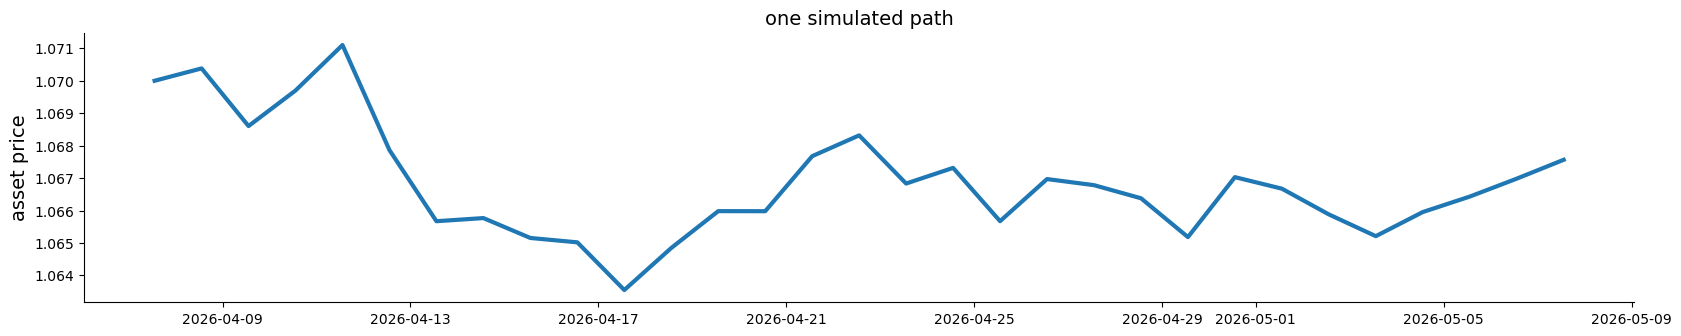

Decision: SELL
I sell if I get more than         : 1.064444583300873
Current swap price (with slippage): 1.06465


In [115]:
from dope.rwa import RWA

rwa = RWA(
    V0=1.07,
    gamma=gamma,
    model="gbm",
    model_params={
        "mu": -0.0001*365.25,
        "sigma": 0.0015*np.sqrt(365.25),
    },
    seed=42,
)
gbm_path = rwa.simulate_path_with_timestamps(n_days=30)


decision = rwa.decide(n_days=30, slippage=0.005)

print("Decision:", decision["decision"])
print("I sell if I get more than         :", decision["L_wait"])
print("Current swap price (with slippage):", decision["X_sell"])

# How to price rUSD as a `GMB` with Jumps (jump-diffusion) model

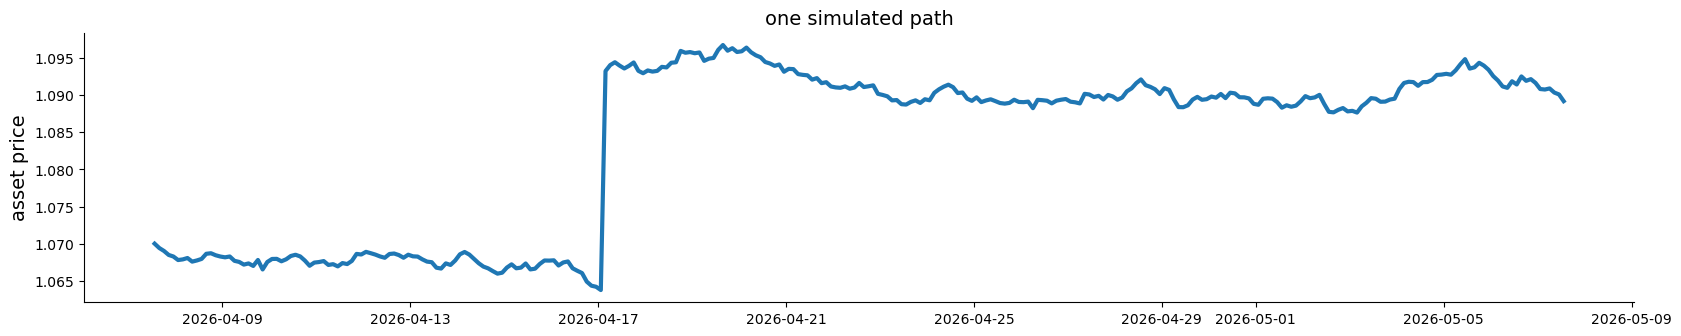

Decision: HOLD
I sell if I get more than         : 1.0714859689556584
Current swap price (with slippage): 1.06465


In [124]:
from dope.rwa import RWA

rwa = RWA(
    V0=1.07,
    gamma=gamma,
    model="gbm_jump",
    model_params={
        "mu": -0.0001*365.25,
        "sigma": 0.0015*np.sqrt(365.25),
        "lambda_pos": 12,
        "lambda_neg": 0.0,
        "jump_mean_pos": 0.01,
        "jump_std_pos": 0.01,
        "jump_mean_neg": 0.01,
        "jump_std_neg": 0.01,
    },
    seed=40,
)
gbm_path = rwa.simulate_path_with_timestamps(n_days=30, step_size=0.1)


decision = rwa.decide(n_days=30, slippage=0.005)

print("Decision:", decision["decision"])
print("I sell if I get more than         :", decision["L_wait"])
print("Current swap price (with slippage):", decision["X_sell"])

# Mean reverting processes

For reference, we show an example of the pricer working with a mean-reverting process (like a yield from a yield token)

### Cox-Ingersoll-Ross (CIR) mean-reverting square-root diffusion.

Continuous-time model:

$$
dV_t = \kappa(\theta - V_t)\,dt + \sigma\sqrt{V_t}\,dW_t
$$

where:
- $\kappa$ is the mean-reversion speed,
- $\theta$ is the long-run level,
- $\sigma$ is the diffusion scale,
- $W_t$ is a Wiener process.


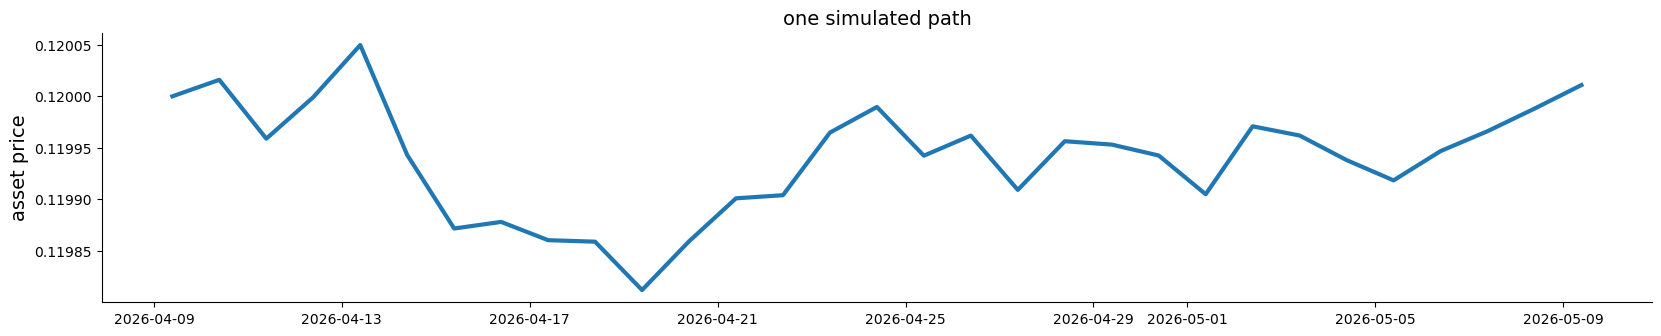

Decision: HOLD
I sell if I get more than         : 0.1199819601962667
Current swap price (with slippage): 0.11939999999999999


In [514]:
rwa = RWA(
    V0=0.12, # current APY
    gamma=gamma,
    model="cir",
    model_params={
        "sigma": 0.003,
        "kappa":0.01,
        "theta":0.1,
    },
    seed=42,
)
gbm_path = rwa.simulate_path_with_timestamps(n_days=30)


decision = rwa.decide(n_days=30, slippage=0.005)

print("Decision:", decision["decision"])
print("I sell if I get more than         :", decision["L_wait"])
print("Current swap price (with slippage):", decision["X_sell"])
